<a href="https://colab.research.google.com/github/diipperss/DNN_GroupProject/blob/main/PartD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Part D: Gender Classification

---

In [1]:
pip install -q torch torchvision pandas matplotlib scikit-learn seaborn gdown

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.datasets import CelebA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
#config
IMG_SIZE = 128
BATCH_SIZE = 64
EPOCHS = 5
LR = 0.001
TRAIN_PER_CLASS = 2500
VAL_PER_CLASS = 500
TEST_PER_CLASS = 500

CLASS_NAMES = ["female", "male"]

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

train_base = CelebA(
    root="./data",
    split="train",
    target_type="attr",
    download=True,
    transform=train_transform
)
val_base = CelebA(
    root="./data",
    split="valid",
    target_type="attr",
    download=True,
    transform=eval_transform
)
test_base = CelebA(
    root="./data",
    split="test",
    target_type="attr",
    download=True,
    transform=eval_transform
)

male_idx = train_base.attr_names.index("Male")
print("Male attribute index:", male_idx)

Downloading...
From (original): https://drive.google.com/uc?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM
From (redirected): https://drive.usercontent.google.com/download?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM&confirm=t&uuid=431d13e9-bb0a-4251-87f6-eda673e59826
To: /content/data/celeba/img_align_celeba.zip
100%|██████████| 1.44G/1.44G [00:11<00:00, 121MB/s] 
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pblRyaVFSWGxPY0U
To: /content/data/celeba/list_attr_celeba.txt
100%|██████████| 26.7M/26.7M [00:00<00:00, 77.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS
To: /content/data/celeba/identity_CelebA.txt
100%|██████████| 3.42M/3.42M [00:00<00:00, 21.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pbThiMVRxWXZ4dU0
To: /content/data/celeba/list_bbox_celeba.txt
100%|██████████| 6.08M/6.08M [00:00<00:00, 33.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pd0FJY3Blby1HUTQ
To: /content/data/celeba/list_landm

Male attribute index: 20


In [5]:
class GenderDataset(Dataset):
    def __init__(self, base_dataset, attr_index):
        self.base_dataset = base_dataset
        self.attr_index = attr_index

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, attrs = self.base_dataset[idx]
        label = int(attrs[self.attr_index] > 0)
        return image, torch.tensor(label, dtype=torch.long)


def balanced_subset(base_dataset, attr_index, samples_per_class):
    labels = (base_dataset.attr[:, attr_index] > 0).long()
    selected = []

    for label in [0, 1]:
        indices = torch.where(labels == label)[0]
        generator = torch.Generator().manual_seed(SEED + label)
        indices = indices[torch.randperm(len(indices), generator=generator)]
        selected.extend(indices[:samples_per_class].tolist())

    return selected


train_dataset = GenderDataset(train_base, male_idx)
val_dataset = GenderDataset(val_base, male_idx)
test_dataset = GenderDataset(test_base, male_idx)

train_indices = balanced_subset(train_base, male_idx, TRAIN_PER_CLASS)
val_indices = balanced_subset(val_base, male_idx, VAL_PER_CLASS)
test_indices = balanced_subset(test_base, male_idx, TEST_PER_CLASS)

train_dataset = Subset(train_dataset, train_indices)
val_dataset = Subset(val_dataset, val_indices)
test_dataset = Subset(test_dataset, test_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 5000
Val size: 1000
Test size: 1000


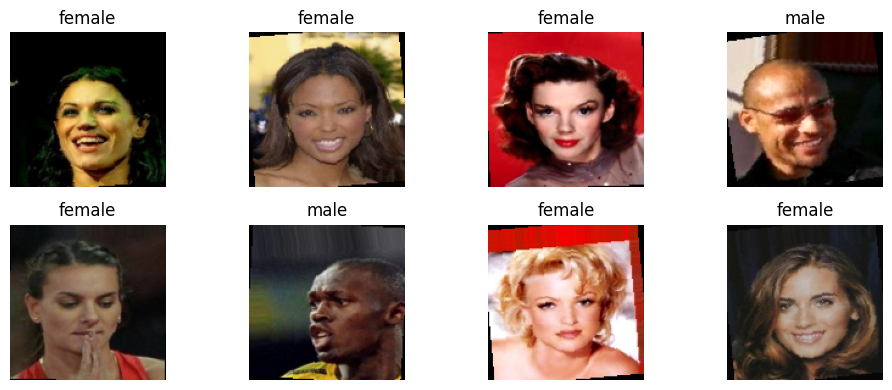

In [6]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))
for i in range(8):
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5) + 0.5
    plt.subplot(2, 4, i + 1)
    plt.imshow(np.clip(img, 0, 1))
    plt.title(CLASS_NAMES[labels[i].item()])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [7]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dilation=1):
        super().__init__()
        padding = dilation

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                in_channels,
                kernel_size=3,
                padding=padding,
                dilation=dilation,
                groups=in_channels,
                bias=False
            ),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class ResidualDSBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dilation=1):
        super().__init__()
        self.conv = DepthwiseSeparableConv(in_channels, out_channels, dilation=dilation)

        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv(x)
        shortcut = self.shortcut(x)
        return self.relu(out + shortcut)


class GenderCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        self.features = nn.Sequential(
            nn.MaxPool2d(2),

            ResidualDSBlock(32, 64, dilation=1),
            nn.MaxPool2d(2),

            ResidualDSBlock(64, 128, dilation=2),
            nn.MaxPool2d(2),

            ResidualDSBlock(128, 256, dilation=1),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.classifier(x)
        return x


model = GenderCNN(num_classes=2).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", num_params)

Trainable parameters: 124354


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1
)


def train_one_epoch():
    model.train()
    total_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())

    avg_loss = total_loss / len(train_loader)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


def evaluate(loader):
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, all_labels, all_preds

In [9]:
history = []
best_val_acc = 0.0
best_model_path = "best_gender_model.pth"
patience = 3
patience_counter = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc, _, _ = evaluate(val_loader)

    scheduler.step(val_acc)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "lr": optimizer.param_groups[0]["lr"]
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
    else:
        patience_counter += 1

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
    print("-" * 30)

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

Epoch 1/5
Train Loss: 0.6349 | Train Acc: 0.6298
Val Loss: 0.5930 | Val Acc: 0.6730
Learning Rate: 0.001000
------------------------------
Epoch 2/5
Train Loss: 0.4987 | Train Acc: 0.7698
Val Loss: 0.4259 | Val Acc: 0.8050
Learning Rate: 0.001000
------------------------------
Epoch 3/5
Train Loss: 0.4316 | Train Acc: 0.8052
Val Loss: 0.4892 | Val Acc: 0.7660
Learning Rate: 0.001000
------------------------------
Epoch 4/5
Train Loss: 0.3852 | Train Acc: 0.8348
Val Loss: 0.5534 | Val Acc: 0.7660
Learning Rate: 0.000500
------------------------------
Epoch 5/5
Train Loss: 0.3270 | Train Acc: 0.8680
Val Loss: 0.2789 | Val Acc: 0.8830
Learning Rate: 0.000500
------------------------------


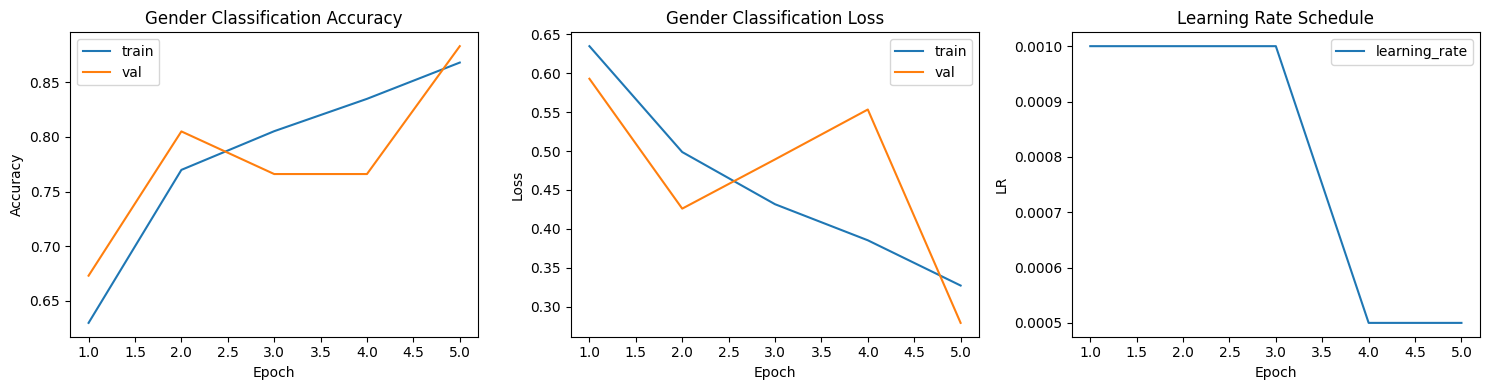

In [10]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(history_df["epoch"], history_df["train_acc"], label="train")
plt.plot(history_df["epoch"], history_df["val_acc"], label="val")
plt.title("Gender Classification Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val")
plt.title("Gender Classification Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history_df["epoch"], history_df["lr"], label="learning_rate")
plt.title("Learning Rate Schedule")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.legend()

plt.tight_layout()
plt.show()

Test Loss: 0.2642
Test Accuracy: 0.8850


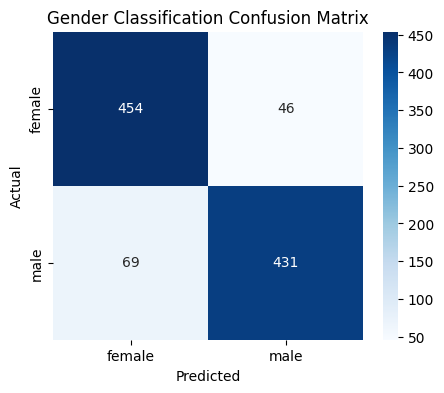

              precision    recall  f1-score   support

      female       0.87      0.91      0.89       500
        male       0.90      0.86      0.88       500

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.88      1000
weighted avg       0.89      0.89      0.88      1000



In [11]:
model.load_state_dict(torch.load("best_gender_model.pth", map_location=device))

test_loss, test_acc, y_true, y_pred = evaluate(test_loader)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title("Gender Classification Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

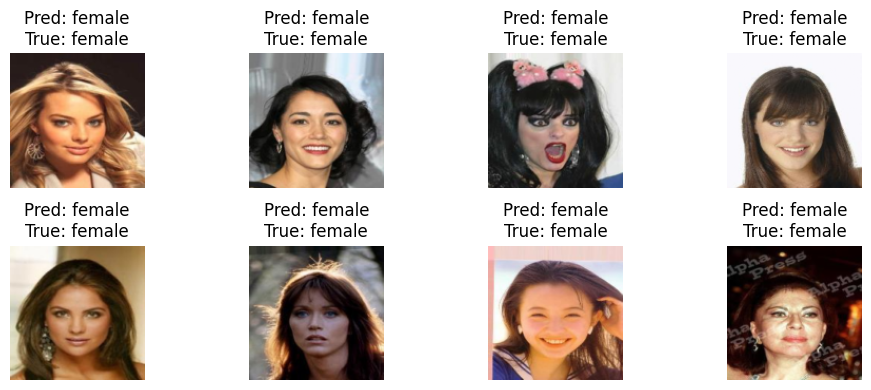

In [12]:
model.load_state_dict(torch.load("best_gender_model.pth", map_location=device))
model.eval()

images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs = model(images.to(device))
    preds = torch.argmax(outputs, dim=1).cpu()

plt.figure(figsize=(10, 4))
for i in range(8):
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5) + 0.5

    plt.subplot(2, 4, i + 1)
    plt.imshow(np.clip(img, 0, 1))
    plt.title(f"Pred: {CLASS_NAMES[preds[i].item()]}\nTrue: {CLASS_NAMES[labels[i].item()]}")
    plt.axis("off")

plt.tight_layout()
plt.show()